# DLA + DBM

In [1]:
%matplotlib ipympl


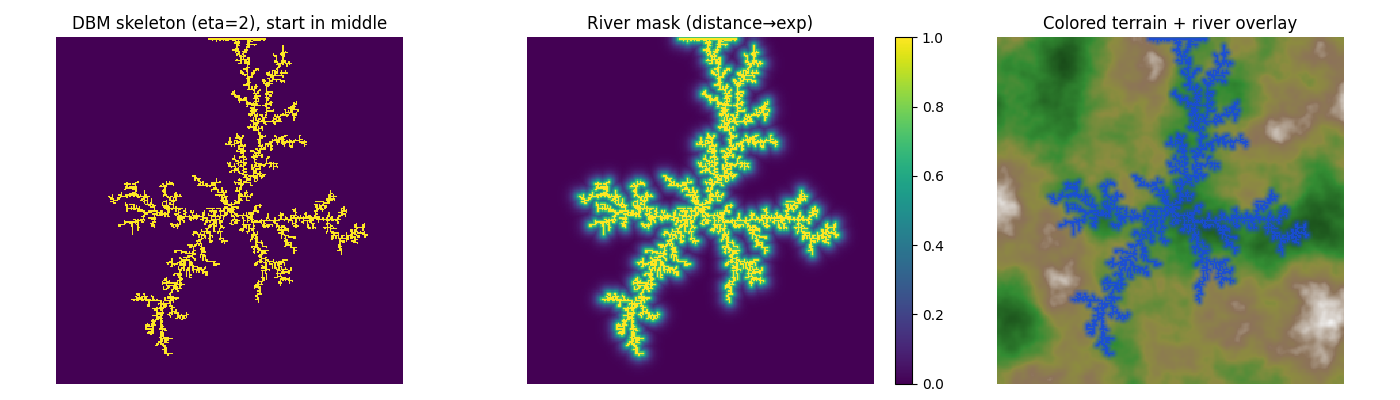

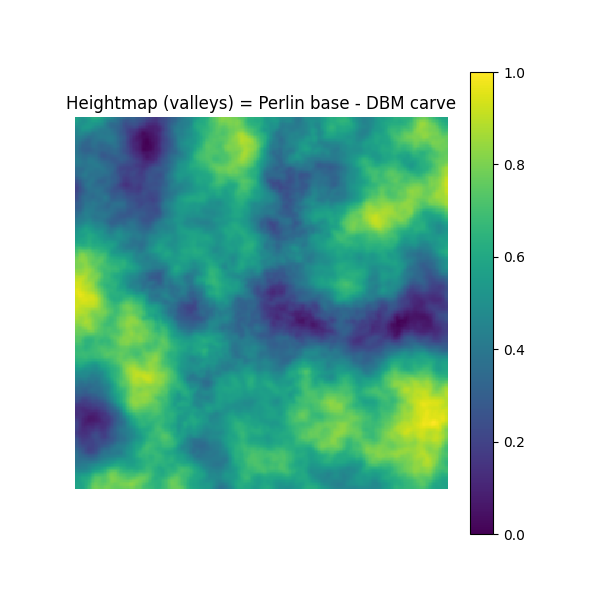

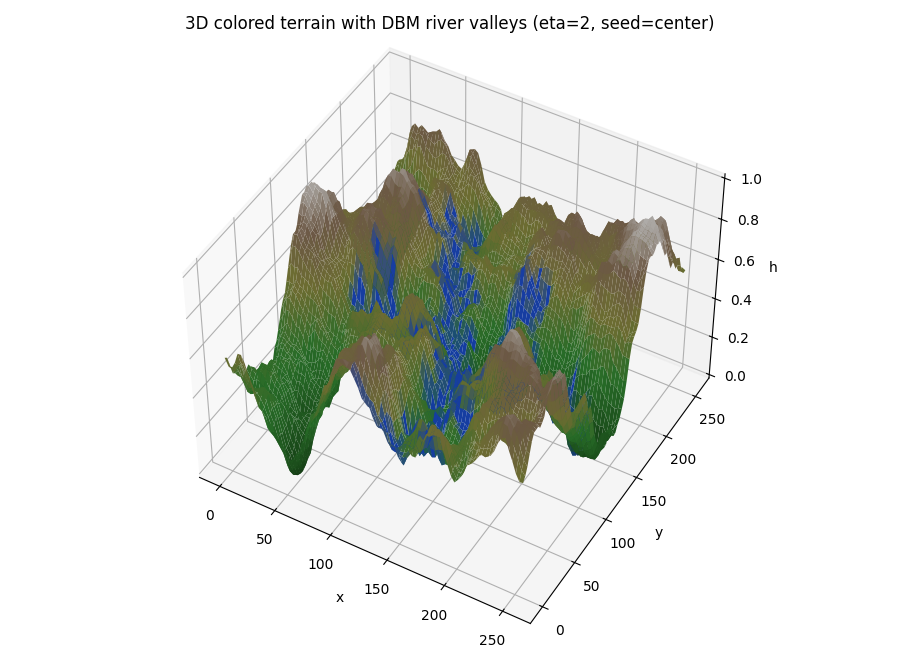

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, gaussian_filter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Perlin fBm base (same as before)
# -----------------------------
def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def perlin2d(H, W, res_y, res_x, seed=0):
    rng = np.random.default_rng(seed)
    angles = rng.random((res_y + 1, res_x + 1)) * 2.0 * np.pi
    grads = np.stack([np.cos(angles), np.sin(angles)], axis=-1).astype(np.float32)

    y = np.linspace(0, res_y, H, endpoint=False, dtype=np.float32)
    x = np.linspace(0, res_x, W, endpoint=False, dtype=np.float32)
    yy, xx = np.meshgrid(y, x, indexing="ij")

    y0 = np.floor(yy).astype(int)
    x0 = np.floor(xx).astype(int)
    y1 = y0 + 1
    x1 = x0 + 1

    sy = yy - y0
    sx = xx - x0

    g00 = grads[y0, x0]
    g10 = grads[y1, x0]
    g01 = grads[y0, x1]
    g11 = grads[y1, x1]

    d00 = np.stack([sx,     sy    ], axis=-1)
    d10 = np.stack([sx,     sy-1.0], axis=-1)
    d01 = np.stack([sx-1.0, sy    ], axis=-1)
    d11 = np.stack([sx-1.0, sy-1.0], axis=-1)

    n00 = (g00 * d00).sum(axis=-1)
    n10 = (g10 * d10).sum(axis=-1)
    n01 = (g01 * d01).sum(axis=-1)
    n11 = (g11 * d11).sum(axis=-1)

    u = fade(sx)
    v = fade(sy)
    nx0 = lerp(n00, n01, u)
    nx1 = lerp(n10, n11, u)
    nxy = lerp(nx0, nx1, v)
    return nxy.astype(np.float32)

def fbm_perlin(H, W, base_res=4, octaves=6, lacunarity=2.0, persistence=0.5, seed=0):
    h = np.zeros((H, W), dtype=np.float32)
    amp = 1.0
    res = float(base_res)
    for o in range(octaves):
        ry = max(1, int(round(res)))
        rx = max(1, int(round(res)))
        h += amp * perlin2d(H, W, ry, rx, seed=seed + 101 * o)
        amp *= persistence
        res *= lacunarity
    h -= h.min()
    h /= (h.max() - h.min() + 1e-12)
    return h

# -----------------------------
# DBM (eta=2) starting from the middle
# -----------------------------
def solve_laplace_jacobi(phi, cluster, n_sweeps=80):
    H, W = phi.shape
    boundary = np.zeros_like(cluster, dtype=bool)
    boundary[0,:] = boundary[-1,:] = True
    boundary[:,0] = boundary[:,-1] = True

    phi = phi.copy()
    phi[cluster] = 0.0
    phi[boundary] = 1.0
    for _ in range(n_sweeps):
        phin = phi.copy()
        phin[1:-1, 1:-1] = 0.25 * (
            phi[0:-2, 1:-1] + phi[2:  , 1:-1] +
            phi[1:-1, 0:-2] + phi[1:-1, 2:  ]
        )
        phin[cluster] = 0.0
        phin[boundary] = 1.0
        phi = phin
    return phi

def boundary_candidates(cluster):
    up    = np.roll(cluster, -1, axis=0)
    down  = np.roll(cluster,  1, axis=0)
    left  = np.roll(cluster, -1, axis=1)
    right = np.roll(cluster,  1, axis=1)
    cand = (up | down | left | right) & (~cluster)
    cand[0,:]=cand[-1,:]=cand[:,0]=cand[:,-1]=False
    return cand

def grad_mag(phi):
    gx = 0.5 * (phi[1:-1, 2:] - phi[1:-1, 0:-2])
    gy = 0.5 * (phi[2:, 1:-1] - phi[0:-2, 1:-1])
    g = np.zeros_like(phi)
    g[1:-1, 1:-1] = np.sqrt(gx*gx + gy*gy)
    return g

def dbm_grow_center(H=192, W=192, n_particles=4200, eta=2.0,
                   relax_every=8, relax_sweeps=80, seed=3):
    rng = np.random.default_rng(seed)
    cluster = np.zeros((H, W), dtype=bool)
    cy, cx = H//2, W//2
    cluster[cy, cx] = True

    phi = np.ones((H, W), dtype=np.float32)
    phi = solve_laplace_jacobi(phi, cluster, n_sweeps=relax_sweeps)

    for t in range(n_particles):
        if t % relax_every == 0:
            phi = solve_laplace_jacobi(phi, cluster, n_sweeps=relax_sweeps)

        cand = boundary_candidates(cluster)
        if not np.any(cand):
            break

        g = grad_mag(phi)
        w = (g[cand] + 1e-12) ** eta
        wsum = float(w.sum())
        if wsum <= 0:
            idx = rng.integers(0, w.size)
        else:
            r = rng.random() * wsum
            idx = int(np.searchsorted(np.cumsum(w), r))

        ys, xs = np.nonzero(cand)
        y, x = ys[idx], xs[idx]
        cluster[y, x] = True

    phi = solve_laplace_jacobi(phi, cluster, n_sweeps=relax_sweeps)
    return cluster, phi

def normalize01(a):
    a = a.astype(np.float32)
    amin, amax = float(a.min()), float(a.max())
    return (a - amin) / (amax - amin + 1e-12)

def river_field_from_cluster(cluster, sigma=3.0, gamma=1.7):
    d = distance_transform_edt(~cluster).astype(np.float32)
    r = np.exp(- (d / sigma) ** gamma)
    return normalize01(r)

# -----------------------------
# Simple terrain coloring + river overlay (RGB)
# -----------------------------
def terrain_colormap(h):
    """
    Very simple piecewise color ramp for terrain.
    Returns RGB in [0,1].
    """
    h = np.clip(h, 0, 1)
    rgb = np.zeros(h.shape + (3,), dtype=np.float32)

    # Control points: (height, color)
    pts = np.array([0.00, 0.35, 0.60, 0.80, 1.00], dtype=np.float32)
    cols = np.array([
        [0.10, 0.30, 0.10],  # dark green (low)
        [0.20, 0.55, 0.20],  # green
        [0.55, 0.55, 0.25],  # olive / dry grass
        [0.55, 0.45, 0.35],  # brown/rock
        [0.95, 0.95, 0.95],  # snow
    ], dtype=np.float32)

    # Piecewise linear interpolation
    for k in range(len(pts) - 1):
        a, b = pts[k], pts[k+1]
        mask = (h >= a) & (h <= b) if k == len(pts) - 2 else (h >= a) & (h < b)
        t = (h[mask] - a) / (b - a + 1e-12)
        rgb[mask] = (1 - t)[:, None] * cols[k] + t[:, None] * cols[k+1]
    return rgb

def overlay_rivers(rgb, river, river_color=(0.10, 0.30, 0.85), strength=0.9, threshold=0.25):
    """
    Blend a blue-ish river color into the terrain where river mask is high.
    """
    river = np.clip(river, 0, 1)
    a = np.zeros_like(river, dtype=np.float32)
    a[river > threshold] = strength * (river[river > threshold] - threshold) / (1 - threshold + 1e-12)
    a = np.clip(a, 0, 1)

    rc = np.array(river_color, dtype=np.float32)[None, None, :]
    out = (1 - a[..., None]) * rgb + a[..., None] * rc
    return out, a

def plot_terrain_3d_colored(h, rgb, title, stride=3, elev=45, azim=-60):
    H, W = h.shape
    y = np.arange(H)
    x = np.arange(W)
    X, Y = np.meshgrid(x, y)
    Xs = X[::stride, ::stride]
    Ys = Y[::stride, ::stride]
    Zs = h[::stride, ::stride]
    Cs = rgb[::stride, ::stride, :]

    fig = plt.figure(figsize=(9,6.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.plot_surface(Xs, Ys, Zs, rstride=1, cstride=1, linewidth=0, antialiased=True, facecolors=Cs)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("h")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Build: Perlin base - DBM river carve (eta=2), seed in middle
# -----------------------------
H = W = 256
base = fbm_perlin(H, W, base_res=3, octaves=6, lacunarity=2.0, persistence=0.5, seed=7)

cluster, phi = dbm_grow_center(H, W, n_particles=4200, eta=1.5, relax_every=8, relax_sweeps=90, seed=3)
river = river_field_from_cluster(cluster, sigma=3.0, gamma=1.)

carve_strength = 0.10
terrain = normalize01(base - carve_strength * river)
terrain = gaussian_filter(terrain, sigma=0.8, mode="reflect")
terrain = normalize01(terrain)

rgb = terrain_colormap(terrain)
rgb_riv, alpha_riv = overlay_rivers(rgb, river, strength=0.95, threshold=0.25)

# -----------------------------
# 2D views
# -----------------------------
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("DBM skeleton (eta=2), start in middle"); plt.imshow(cluster, interpolation="nearest"); plt.axis("off")
plt.subplot(1,3,2); plt.title("River mask (distance→exp)"); plt.imshow(river, interpolation="nearest"); plt.axis("off"); plt.colorbar(fraction=0.046)
plt.subplot(1,3,3); plt.title("Colored terrain + river overlay"); plt.imshow(rgb_riv, interpolation="nearest"); plt.axis("off")
plt.tight_layout()
plt.show()

# Also show the carved terrain in grayscale
plt.figure(figsize=(6,6))
plt.title("Heightmap (valleys) = Perlin base - DBM carve")
plt.imshow(terrain, interpolation="nearest")
plt.axis("off")
plt.colorbar()
plt.show()

# -----------------------------
# 3D colored surface
# -----------------------------
plot_terrain_3d_colored(terrain, rgb_riv, "3D colored terrain with DBM river valleys (eta=2, seed=center)", stride=3)




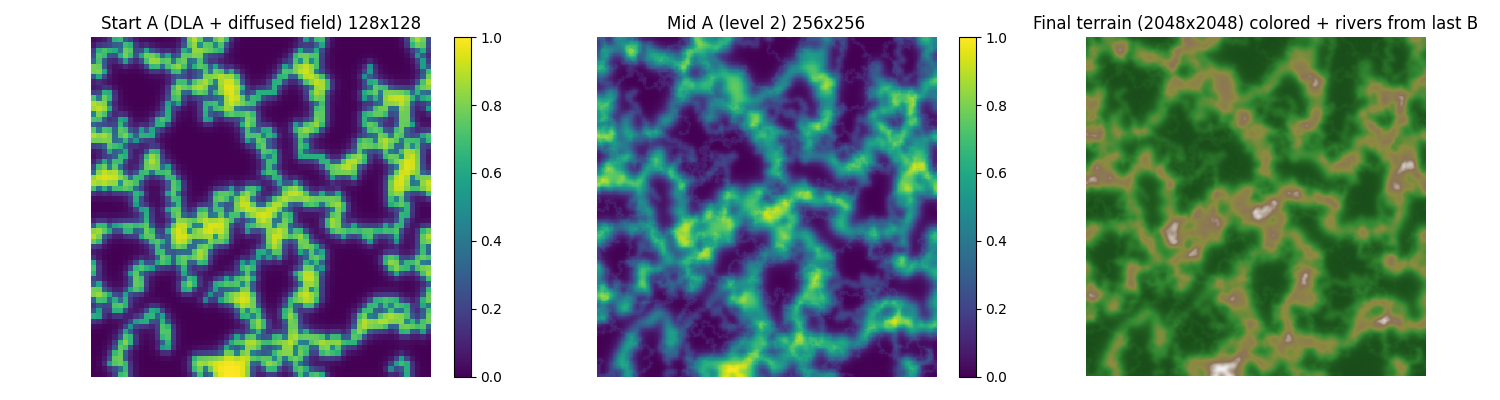

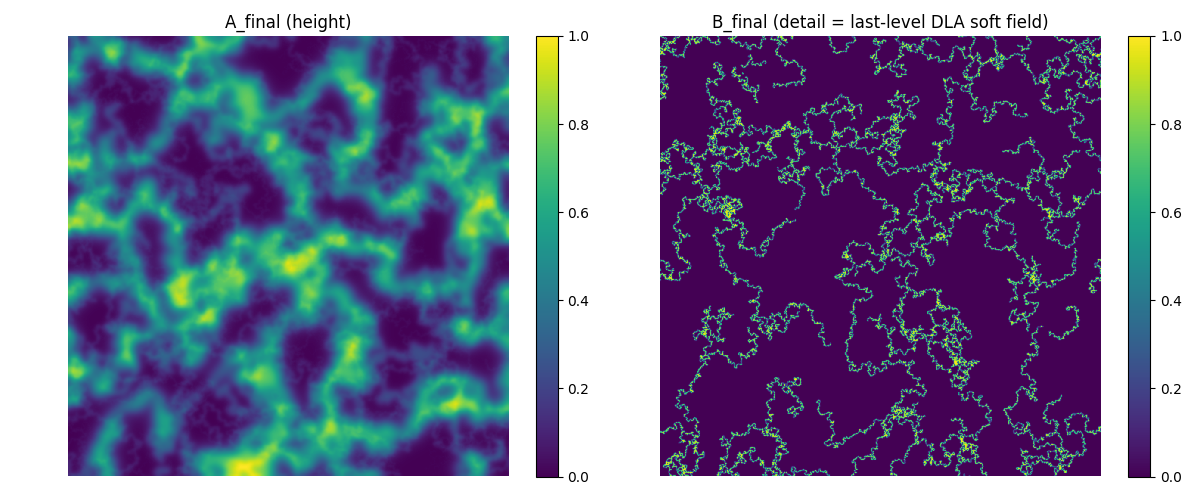

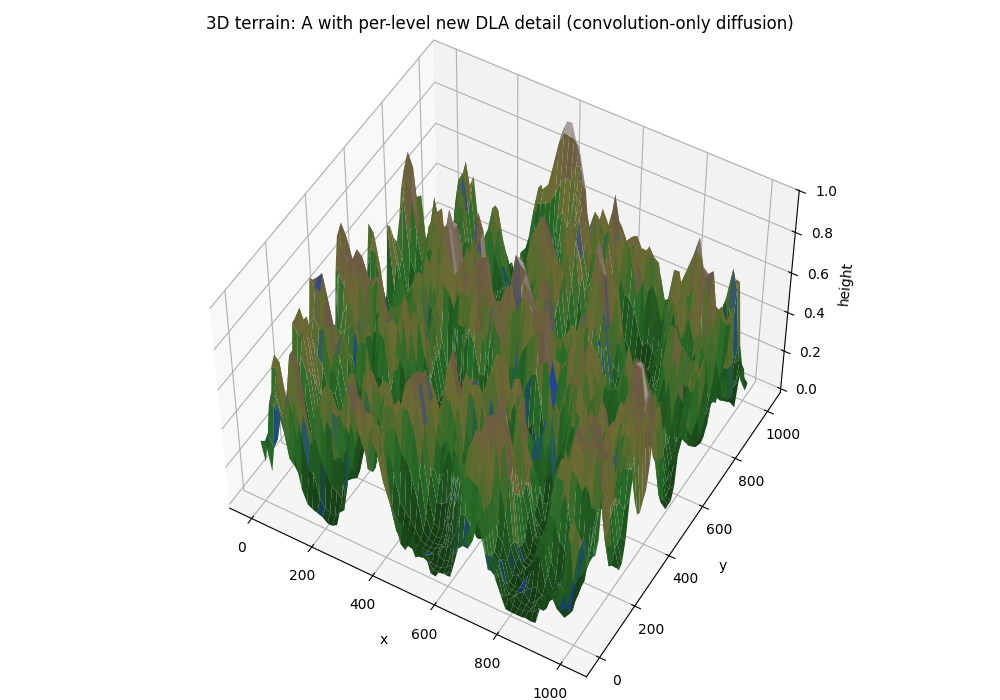

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, zoom
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Utilities
# -----------------------------
def normalize01(a: np.ndarray) -> np.ndarray:
    a = a.astype(np.float32, copy=False)
    mn, mx = float(a.min()), float(a.max())
    return (a - mn) / (mx - mn + 1e-12)

def bilinear_resize(img: np.ndarray, new_h: int, new_w: int, mode: str = "reflect") -> np.ndarray:
    h, w = img.shape
    out = zoom(img.astype(np.float32, copy=False), (new_h / h, new_w / w), order=1, mode=mode, prefilter=False)
    out = out[:new_h, :new_w]
    if out.shape != (new_h, new_w):
        out = np.pad(out, ((0, max(0, new_h - out.shape[0])),
                           (0, max(0, new_w - out.shape[1]))), mode="edge")
        out = out[:new_h, :new_w]
    return out

def box_blur(img: np.ndarray, radius: int, mode: str = "reflect") -> np.ndarray:
    r = int(radius)
    if r <= 0:
        return img.astype(np.float32, copy=False)
    k = np.ones((2*r + 1, 2*r + 1), dtype=np.float32)
    k /= k.sum()
    return convolve(img.astype(np.float32, copy=False), k, mode=mode)

# -----------------------------
# Fast "DLA-like" branching skeleton (as in your C++ snippet spirit)
# -----------------------------
def rand_unit_vec3(rng: np.random.Generator) -> np.ndarray:
    v = rng.normal(size=3).astype(np.float32)
    return v / (np.linalg.norm(v) + 1e-12)

def setpixel_max_wrap(arr: np.ndarray, y: int, x: int, v: float) -> None:
    H, W = arr.shape
    yy, xx = y % H, x % W
    arr[yy, xx] = max(float(v), float(arr[yy, xx]))

def getpixel_wrap(arr: np.ndarray, y: int, x: int) -> float:
    H, W = arr.shape
    return float(arr[y % H, x % W])

def line_midpoint_disp_points(arr: np.ndarray, a, b, rng: np.random.Generator,
                              min_len=1.0, rough=0.48, z_bias=1.0):
    ax, ay, az = a
    bx, by, bz = b
    dx, dy = ax - bx, ay - by
    length = float(np.sqrt(dx*dx + dy*dy))
    if length < min_len:
        return

    rnd = rand_unit_vec3(rng)
    rnd[2] += z_bias

    mx = 0.5 * (ax + bx) + rnd[0] * length * rough
    my = 0.5 * (ay + by) + rnd[1] * length * rough
    mz = 0.5 * (az + bz) + rnd[2] * length * rough

    setpixel_max_wrap(arr, int(round(my)), int(round(mx)), mz)

    line_midpoint_disp_points(arr, (ax, ay, az), (mx, my, mz), rng, min_len=min_len, rough=rough, z_bias=z_bias)
    line_midpoint_disp_points(arr, (mx, my, mz), (bx, by, bz), rng, min_len=min_len, rough=rough, z_bias=z_bias)

def generate_branching_skeleton(N: int, max_points: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    ink = np.zeros((N, N), dtype=np.float32)
    nodes = [(N/2.0, N/2.0, 100.0)]
    setpixel_max_wrap(ink, N//2, N//2, 1.0)

    radmax = max(6, int(N * 16 / 1024))
    radmax2 = int(N / 3)

    for i in range(max_points):
        idx = int(rng.integers(0, len(nodes)))
        vx, vy, vz = nodes[idx]

        angle = rng.random() * (2*np.pi)
        radius = (int(rng.integers(0, radmax)) + radmax) * (((i*i) & 3) + 1) * ((i & 7) + 1)
        radius = min(radius, radmax2)

        px = np.sin(angle) * radius
        py = np.cos(angle) * radius
        pz = float(int(rng.integers(0, 111)) - vz)

        steps = max(12, int(4 * radius))
        skip = False
        for j in range(steps//5, int(steps*5/4) + 1):
            a = float(j) / float(steps)
            qx = vx + px * a
            qy = vy + py * a
            if getpixel_wrap(ink, int(qy), int(qx)) > 0.0:
                skip = True
                break
        if skip:
            continue

        nx, ny, nz = vx + px, vy + py, pz
        line_midpoint_disp_points(
            ink, (vx, vy, vz), (nx, ny, nz), rng,
            min_len=1.0, rough=0.48, z_bias=(seed % 15 + 2) / 7.0
        )
        nodes.append((nx, ny, nz))

    skel = (ink > 0.0).astype(np.float32)
    return skel

# -----------------------------
# "Distance field" approximation via diffusion (convolution only)
# Start from binary skeleton S; diffuse with a small kernel repeatedly.
# -----------------------------
K_DIFF = np.array([[0, 1, 0],
                   [1, 4, 1],
                   [0, 1, 0]], dtype=np.float32)
K_DIFF /= K_DIFF.sum()

def diffuse_field(S: np.ndarray, n_steps: int = 20, inject: float = 0.25) -> np.ndarray:
    """
    n_steps of diffusion: X <- conv(X), then inject a bit of the skeleton to keep ridges sharp.
    All operations are convolutional and pointwise.
    """
    X = S.astype(np.float32, copy=False)
    for _ in range(int(n_steps)):
        X = convolve(X, K_DIFF, mode="reflect")
        if inject > 0:
            X = (1.0 - inject) * X + inject * S
    return normalize01(X)

def make_DLA_soft_field(N: int, seed: int) -> np.ndarray:
    # modest growth with N to keep runtime stable
    max_points = int(np.clip(280 + 0.25 * N, 300, 900))
    S = generate_branching_skeleton(N=N, max_points=max_points, seed=seed)
    # diffusion steps can be a bit higher at high-res to make smooth banks
    steps = int(np.clip(14 + N / 256, 16, 28))
    return diffuse_field(S, n_steps=steps, inject=0.22)

# -----------------------------
# Cascade: B is NEW DLA instance each level; A is bilinear + box blur
#   B_up = new_DLA_soft_field(new_res)
#   A_up = boxblur(bilinear(A))
#   A = normalize(A_up + w_l * B_up)
#   B = B_up
# -----------------------------
def cascade_new_DLA_detail(A0: np.ndarray, target: int = 2048, blur_radius: int = 1,
                           persistence: float = 0.78, seed_base: int = 2026):
    A = A0.astype(np.float32, copy=False)
    B = A0.astype(np.float32, copy=False)
    levels = [(A.copy(), B.copy())]
    lvl = 0
    while A.shape[0] < target:
        lvl += 1
        new_n = min(target, A.shape[0] * 2)

        B_up = make_DLA_soft_field(new_n, seed=seed_base + 1000 * lvl)
        A_up = bilinear_resize(A, new_n, new_n, mode="reflect")
        A_up = box_blur(A_up, radius=blur_radius, mode="reflect")

        w = persistence ** lvl
        A = normalize01(A_up + w * B_up)
        B = B_up
        levels.append((A.copy(), B.copy()))
    return levels

# -----------------------------
# Coloring + 3D plot
# -----------------------------
def terrain_colormap(h: np.ndarray) -> np.ndarray:
    h = np.clip(h, 0, 1)
    rgb = np.zeros(h.shape + (3,), dtype=np.float32)

    pts = np.array([0.00, 0.35, 0.60, 0.80, 1.00], dtype=np.float32)
    cols = np.array([
        [0.10, 0.30, 0.10],  # dark green
        [0.20, 0.55, 0.20],  # green
        [0.55, 0.55, 0.25],  # olive
        [0.55, 0.45, 0.35],  # rock
        [0.95, 0.95, 0.95],  # snow
    ], dtype=np.float32)

    for k in range(len(pts) - 1):
        a, b = pts[k], pts[k + 1]
        mask = (h >= a) & (h <= b) if k == len(pts) - 2 else (h >= a) & (h < b)
        t = (h[mask] - a) / (b - a + 1e-12)
        rgb[mask] = (1 - t)[:, None] * cols[k] + t[:, None] * cols[k + 1]
    return rgb

def overlay_rivers(rgb: np.ndarray, river_mask: np.ndarray, threshold=0.65, strength=0.95) -> np.ndarray:
    r = np.clip(river_mask, 0, 1)
    a = np.zeros_like(r, dtype=np.float32)
    m = r > threshold
    a[m] = strength * (r[m] - threshold) / (1 - threshold + 1e-12)
    a = np.clip(a, 0, 1)
    river_color = np.array([0.10, 0.30, 0.90], dtype=np.float32)[None, None, :]
    return (1 - a[..., None]) * rgb + a[..., None] * river_color

def plot_terrain_3d(h: np.ndarray, rgb: np.ndarray, title: str, stride: int = 16, elev: int = 50, azim: int = -60):
    H, W = h.shape
    y = np.arange(H)
    x = np.arange(W)
    X, Y = np.meshgrid(x, y)
    Xs = X[::stride, ::stride]
    Ys = Y[::stride, ::stride]
    Zs = h[::stride, ::stride]
    Cs = rgb[::stride, ::stride, :]

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.plot_surface(Xs, Ys, Zs, rstride=1, cstride=1, linewidth=0, antialiased=True, facecolors=Cs)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("height")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
N0 = 64
A0 = make_DLA_soft_field(N0, seed=134137)  # initial A = DLA + soft distance-like field

levels = cascade_new_DLA_detail(A0, target=1024, blur_radius=1, persistence=0.3, seed_base=2026)

A_final, B_final = levels[-1]
rgb = terrain_colormap(A_final)
rgb_riv = overlay_rivers(rgb, B_final, threshold=0.62, strength=0.95)

# 2D plots
mid_idx = 2  # 512
A_mid, _B_mid = levels[mid_idx]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("Start A (DLA + diffused field) 128x128")
plt.imshow(A0, interpolation="nearest")
plt.axis("off")
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title(f"Mid A (level {mid_idx}) {A_mid.shape[0]}x{A_mid.shape[1]}")
plt.imshow(A_mid, interpolation="nearest")
plt.axis("off")
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Final terrain (2048x2048) colored + rivers from last B")
plt.imshow(rgb, interpolation="nearest")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("A_final (height)")
plt.imshow(A_final, interpolation="nearest")
plt.axis("off")
plt.colorbar(fraction=0.046)

plt.subplot(1, 2, 2)
plt.title("B_final (detail = last-level DLA soft field)")
plt.imshow(B_final, interpolation="nearest")
plt.axis("off")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

# 3D plot (subsampled)
plot_terrain_3d(A_final, rgb_riv, "3D terrain: A with per-level new DLA detail (convolution-only diffusion)", stride=16, elev=50, azim=-60)



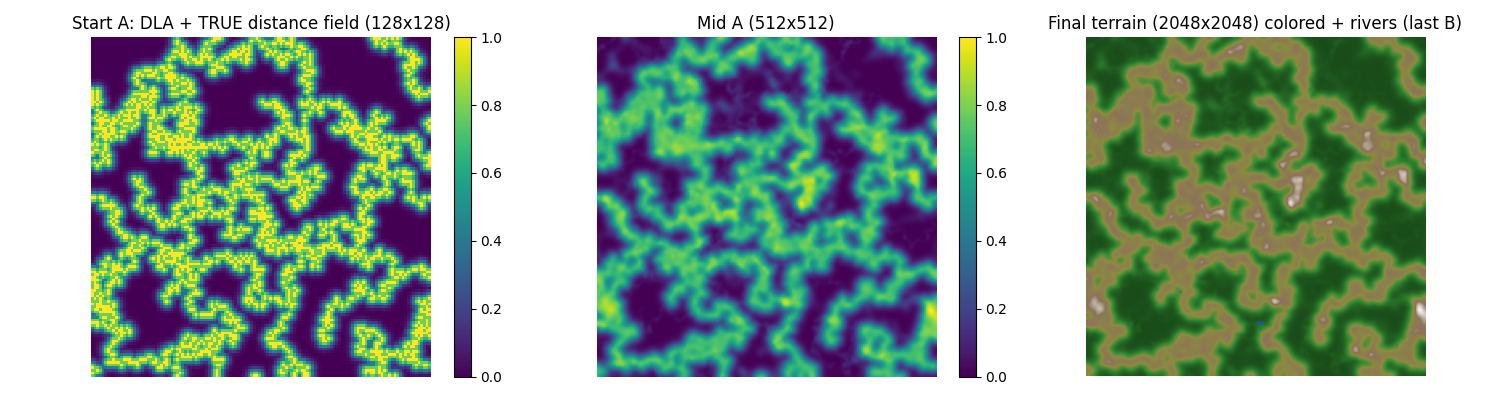

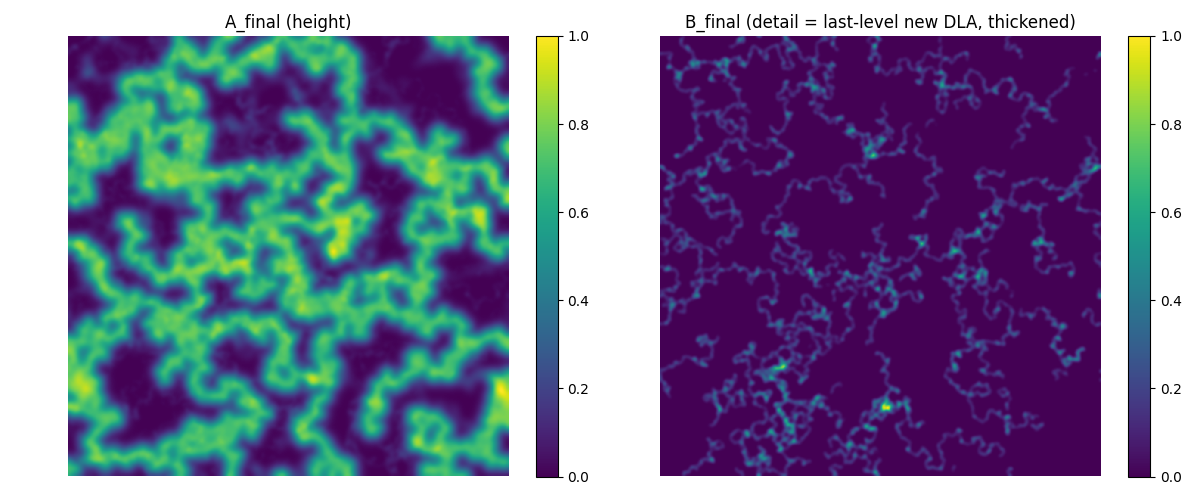

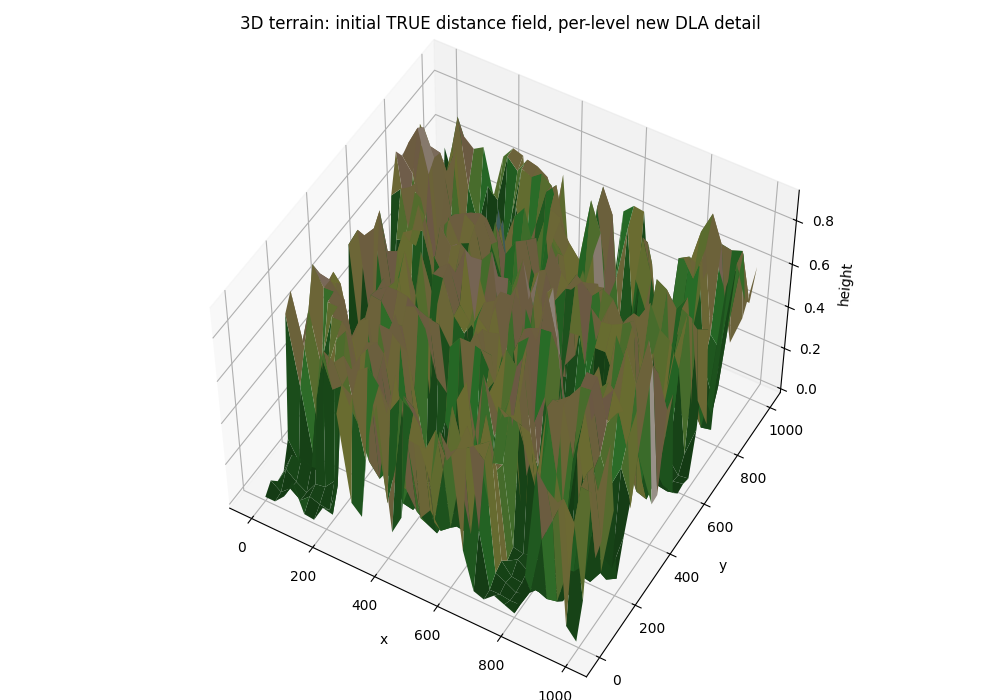

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, distance_transform_edt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def normalize01(a):
    a = a.astype(np.float32, copy=False)
    mn, mx = float(a.min()), float(a.max())
    return (a - mn) / (mx - mn + 1e-12)

def bilinear_resize(img, new_h, new_w, mode="reflect"):
    h, w = img.shape
    out = zoom(img.astype(np.float32, copy=False), (new_h / h, new_w / w), order=1, mode=mode, prefilter=False)
    out = out[:new_h, :new_w]
    if out.shape != (new_h, new_w):
        out = np.pad(out, ((0, max(0, new_h - out.shape[0])), (0, max(0, new_w - out.shape[1]))), mode="edge")
        out = out[:new_h, :new_w]
    return out

def box_blur_fast(img, r):
    """Separable box blur via cumulative sums; preserves shape exactly."""
    r = int(r)
    if r <= 0:
        return img.astype(np.float32, copy=False)
    x = img.astype(np.float32, copy=False)
    H, W = x.shape

    # Horizontal
    xh = np.pad(x, ((0, 0), (r, r)), mode="edge")  # (H, W+2r)
    c = np.cumsum(xh, axis=1, dtype=np.float32)
    c = np.concatenate([np.zeros((H, 1), dtype=np.float32), c], axis=1)  # (H, W+2r+1)
    xh = (c[:, 2*r+1:] - c[:, :-2*r-1]) / (2*r+1)  # (H, W)

    # Vertical
    xv = np.pad(xh, ((r, r), (0, 0)), mode="edge")  # (H+2r, W)
    c = np.cumsum(xv, axis=0, dtype=np.float32)
    c = np.concatenate([np.zeros((1, W), dtype=np.float32), c], axis=0)  # (H+2r+1, W)
    out = (c[2*r+1:, :] - c[:-2*r-1, :]) / (2*r+1)  # (H, W)

    return out

# -----------------------------
# DLA-like branching skeleton (fast)
# -----------------------------
def rand_unit_vec3(rng):
    v = rng.normal(size=3).astype(np.float32)
    return v / (np.linalg.norm(v) + 1e-12)

def setpixel_max_wrap(arr, y, x, v):
    H, W = arr.shape
    yy, xx = y % H, x % W
    arr[yy, xx] = max(float(v), float(arr[yy, xx]))

def getpixel_wrap(arr, y, x):
    H, W = arr.shape
    return float(arr[y % H, x % W])

def line_midpoint_disp_points(arr, a, b, rng, min_len=2.0, rough=0.48, z_bias=1.0):
    ax, ay, az = a
    bx, by, bz = b
    dx, dy = ax - bx, ay - by
    length = float(np.sqrt(dx*dx + dy*dy))
    if length < min_len:
        return
    rnd = rand_unit_vec3(rng)
    rnd[2] += z_bias
    mx = 0.5*(ax+bx) + rnd[0]*length*rough
    my = 0.5*(ay+by) + rnd[1]*length*rough
    mz = 0.5*(az+bz) + rnd[2]*length*rough
    setpixel_max_wrap(arr, int(round(my)), int(round(mx)), mz)
    line_midpoint_disp_points(arr, (ax,ay,az), (mx,my,mz), rng, min_len=min_len, rough=rough, z_bias=z_bias)
    line_midpoint_disp_points(arr, (mx,my,mz), (bx,by,bz), rng, min_len=min_len, rough=rough, z_bias=z_bias)

def generate_branching_skeleton(N, seed, max_points=None):
    rng = np.random.default_rng(seed)
    ink = np.zeros((N, N), dtype=np.float32)

    if max_points is None:
        max_points = int(np.clip(220 + 0.10*N, 260, 600))

    nodes = [(N/2.0, N/2.0, 100.0)]
    setpixel_max_wrap(ink, N//2, N//2, 1.0)

    radmax = max(6, int(N * 16 / 1024))
    radmax2 = int(N / 3)
    min_len = max(2.0, N / 512.0)

    for i in range(max_points):
        vx, vy, vz = nodes[int(rng.integers(0, len(nodes)))]
        angle = rng.random() * (2*np.pi)
        radius = (int(rng.integers(0, radmax)) + radmax) * (((i*i)&3)+1) * ((i&7)+1)
        radius = min(radius, radmax2)

        px, py = np.sin(angle)*radius, np.cos(angle)*radius
        pz = float(int(rng.integers(0,111)) - vz)

        steps = max(10, int(3*radius))
        skip = False
        for j in range(max(1, steps//6), int(steps*7/6)+1, 2):
            a = float(j)/float(steps)
            qx, qy = vx + px*a, vy + py*a
            if getpixel_wrap(ink, int(qy), int(qx)) > 0.0:
                skip = True
                break
        if skip:
            continue

        nx, ny, nz = vx+px, vy+py, pz
        line_midpoint_disp_points(ink, (vx,vy,vz), (nx,ny,nz), rng,
                                  min_len=min_len, rough=0.48, z_bias=(seed%15+2)/7.0)
        nodes.append((nx,ny,nz))

    return (ink > 0.0)

# -----------------------------
# Initial true distance field + fast thickening for big N
# -----------------------------
def distance_field_true(skel, sigma=2.2, gamma=1.8):
    d = distance_transform_edt(~skel).astype(np.float32)
    A = np.exp(- (d / float(sigma)) ** float(gamma))
    return normalize01(A)

def thickened_field_fast(skel, blur_r=3, n_passes=4, gamma=1.6):
    x = skel.astype(np.float32)
    for _ in range(int(n_passes)):
        x = box_blur_fast(x, blur_r)
    x = normalize01(x)
    x = x ** gamma
    return normalize01(x)

def make_DLA_field(N, seed, initial=False):
    sk = generate_branching_skeleton(N, seed=seed)
    if initial:
        return distance_field_true(sk, sigma=2.2, gamma=1.8)
    blur_r = 2 if N <= 512 else (3 if N <= 1024 else 4)
    passes = 3 if N <= 512 else 4
    return thickened_field_fast(sk, blur_r=blur_r, n_passes=passes, gamma=1.6)

# -----------------------------
# Cascade: per-level NEW DLA instance for B
# -----------------------------
def cascade_new_DLA_detail(A0, target=1024, blur_radius=2, persistence=0.4, seed_base=2026):
    A = A0.astype(np.float32, copy=False)
    B = A0.astype(np.float32, copy=False)
    snaps = {}
    lvl = 0
    while A.shape[0] < target:
        lvl += 1
        new_n = min(target, A.shape[0]*2)

        B_up = make_DLA_field(new_n, seed=seed_base + 1000*lvl, initial=False)

        A_up = bilinear_resize(A, new_n, new_n)
        A_up = box_blur_fast(A_up, blur_radius)

        w = persistence**lvl
        A = normalize01(A_up + w*B_up)
        B = B_up

        if new_n in (256, 512, 1024, 2048):
            snaps[new_n] = (A.copy(), B.copy())
    return A, B, snaps

# -----------------------------
# Coloring + 3D
# -----------------------------
def terrain_colormap(h):
    h = np.clip(h, 0, 1)
    rgb = np.zeros(h.shape + (3,), dtype=np.float32)
    pts = np.array([0.00, 0.35, 0.60, 0.80, 1.00], dtype=np.float32)
    cols = np.array([
        [0.10, 0.30, 0.10],
        [0.20, 0.55, 0.20],
        [0.55, 0.55, 0.25],
        [0.55, 0.45, 0.35],
        [0.95, 0.95, 0.95],
    ], dtype=np.float32)
    for k in range(len(pts)-1):
        a, b = pts[k], pts[k+1]
        mask = (h >= a) & (h <= b) if k == len(pts)-2 else (h >= a) & (h < b)
        t = (h[mask]-a)/(b-a+1e-12)
        rgb[mask] = (1-t)[:,None]*cols[k] + t[:,None]*cols[k+1]
    return rgb

def overlay_rivers(rgb, river_mask, threshold=0.65, strength=0.95):
    r = np.clip(river_mask, 0, 1)
    a = np.zeros_like(r, dtype=np.float32)
    m = r > threshold
    a[m] = strength*(r[m]-threshold)/(1-threshold+1e-12)
    a = np.clip(a, 0, 1)
    river_color = np.array([0.10, 0.30, 0.90], dtype=np.float32)[None,None,:]
    return (1-a[...,None])*rgb + a[...,None]*river_color

def plot_terrain_3d(h, rgb, title, stride=32, elev=50, azim=-60):
    H, W = h.shape
    y = np.arange(H)[::stride]
    x = np.arange(W)[::stride]
    X, Y = np.meshgrid(x, y)
    Z = h[::stride, ::stride]
    C = rgb[::stride, ::stride, :]
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True, facecolors=C)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("height")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
A0 = make_DLA_field(128, seed=134137, initial=True)  # initial: DLA + TRUE distance field
A_final, B_final, snaps = cascade_new_DLA_detail(A0, target=1024, blur_radius=2, persistence=0.4, seed_base=2026)

rgb = terrain_colormap(A_final)
rgb_riv = overlay_rivers(rgb, B_final, threshold=0.65, strength=0.95)

A_mid = snaps.get(512, (None, None))[0]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("Start A: DLA + TRUE distance field (128x128)")
plt.imshow(A0, interpolation="nearest"); plt.axis("off"); plt.colorbar(fraction=0.046)
plt.subplot(1, 3, 2)
plt.title("Mid A (512x512)")
plt.imshow(A_mid if A_mid is not None else bilinear_resize(A0, 512, 512), interpolation="nearest"); plt.axis("off"); plt.colorbar(fraction=0.046)
plt.subplot(1, 3, 3)
plt.title("Final terrain (2048x2048) colored + rivers (last B)")
plt.imshow(rgb_riv, interpolation="nearest"); plt.axis("off")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("A_final (height)")
plt.imshow(A_final, interpolation="nearest"); plt.axis("off"); plt.colorbar(fraction=0.046)
plt.subplot(1, 2, 2)
plt.title("B_final (detail = last-level new DLA, thickened)")
plt.imshow(B_final, interpolation="nearest"); plt.axis("off"); plt.colorbar(fraction=0.046)
plt.tight_layout(); plt.show()

plot_terrain_3d(A_final, rgb_riv, "3D terrain: initial TRUE distance field, per-level new DLA detail", stride=32, elev=50, azim=-60)



# river basins

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm

def vxy(v: int, L: int) -> tuple[int, int]:
    return (v % L, v // L)

def plot_network_color_by_area(
    parent: np.ndarray,
    area: np.ndarray,
    L: int,
    periodic_x: bool = True,
    title: str = "Drainage tree (colored by area)",
    lw: float = 0.8,
    alpha: float = 0.95,
) -> None:
    """
    Colors each edge by the *upstream area* of its upstream node v (i.e., area[v]).
    Uses log-color scaling (recommended because area is heavy-tailed).
    Handles periodic x plotting by wrapping edges across the boundary.
    """
    segs = []
    vals = []

    for v, p in enumerate(parent):
        if p < 0:
            continue
        x1, y1 = vxy(v, L)
        x2, y2 = vxy(p, L)

        if periodic_x:
            dx = x2 - x1
            if dx >  L // 2:  x2 -= L
            if dx < -L // 2:  x2 += L

        segs.append([(x1, y1), (x2, y2)])
        vals.append(area[v])

    segs = np.asarray(segs, dtype=float)
    vals = np.asarray(vals, dtype=float)

    lc = LineCollection(
        segs,
        cmap="viridis",                 # change if you like
        norm=LogNorm(vmin=max(1, vals.min()), vmax=vals.max()),
        linewidths=lw,
        alpha=alpha,
    )
    lc.set_array(vals)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.add_collection(lc)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlim(0, L - 1)              # keep view in [0, L)
    ax.set_ylim(L - 1, 0)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Drainage area (log scale)")
    plt.show()


# -----------------------
# Use periodic x + single outlet
# -----------------------
# parent = generate_invasion_percolation_tree(L, outlet="single_bottom_center", periodic_x=True, seed=123)
# area  = compute_area(parent)
# plot_network_color_by_area(parent, area, L, periodic_x=True,
#                            title="Invasion Percolation (single outlet, periodic x)")


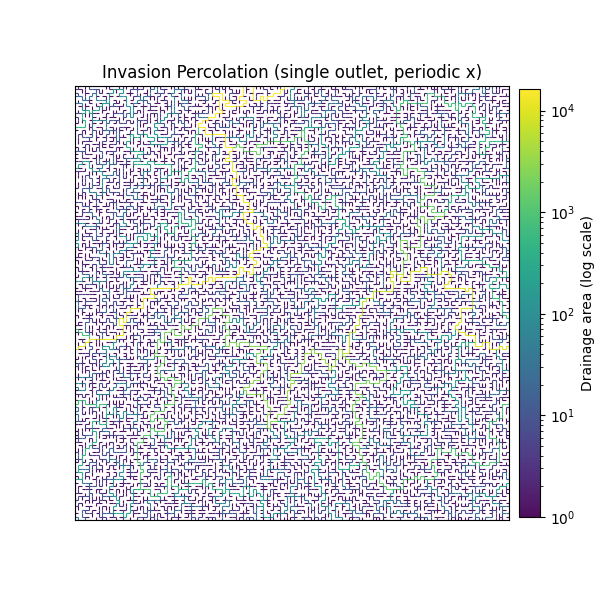

In [21]:
parent = generate_invasion_percolation_tree(L, outlet="single_bottom_center", periodic_x=True, seed=123)
area  = compute_area(parent)
plot_network_color_by_area(parent, area, L, periodic_x=True,
                           title="Invasion Percolation (single outlet, periodic x)")